In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
# Load the dataset\
data = pd.read_csv('diabetes.csv')
# Split the dataset into features and target variable
X = data.drop('Outcome', axis=1)
y = data['Outcome']
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## 1. Data Exploration & Visualization

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Display basic info
print("Dataset Shape:", data.shape)
print("\nDataset Info:")
print(data.info())
print("\nStatistical Summary:")
data.describe()

Dataset Shape: (768, 9)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

Statistical Summary:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


C:\Users\Arnav pareek\AppData\Local\Temp\ipykernel_32944\1802321779.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=data, palette='viridis')


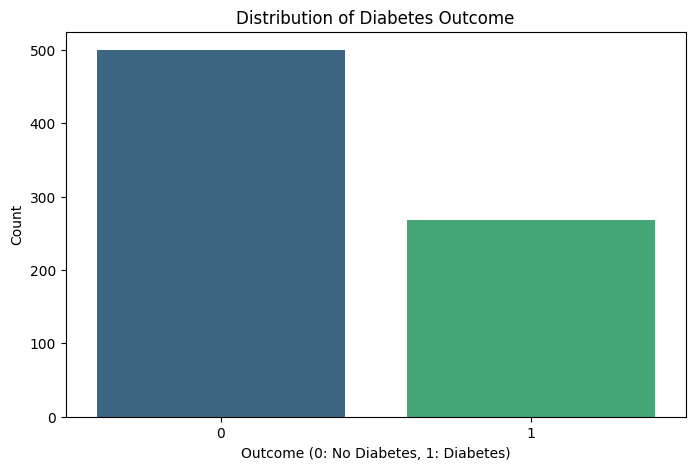

In [5]:
# Check for missing values
print("Missing Values:")
print(data.isnull().sum())

# Check class distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='Outcome', data=data, palette='viridis')
plt.title('Distribution of Diabetes Outcome')
plt.xlabel('Outcome (0: No Diabetes, 1: Diabetes)')
plt.ylabel('Count')
plt.show()

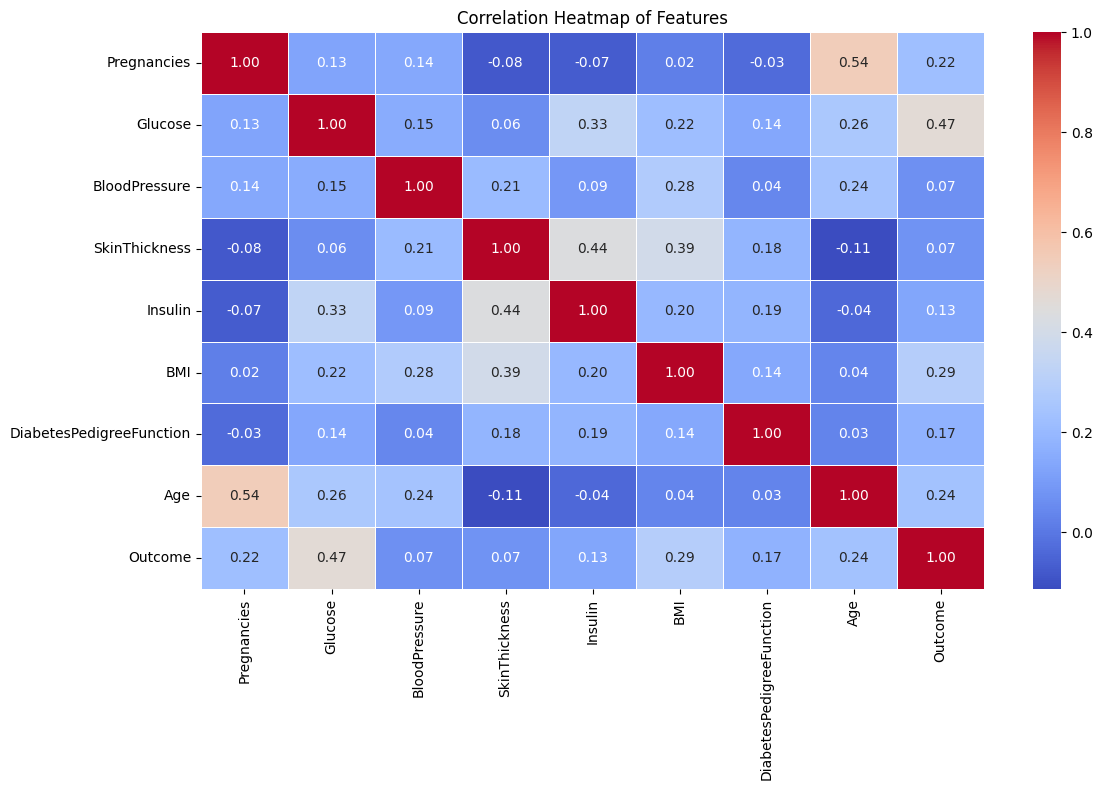

In [6]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Features')
plt.tight_layout()
plt.show()

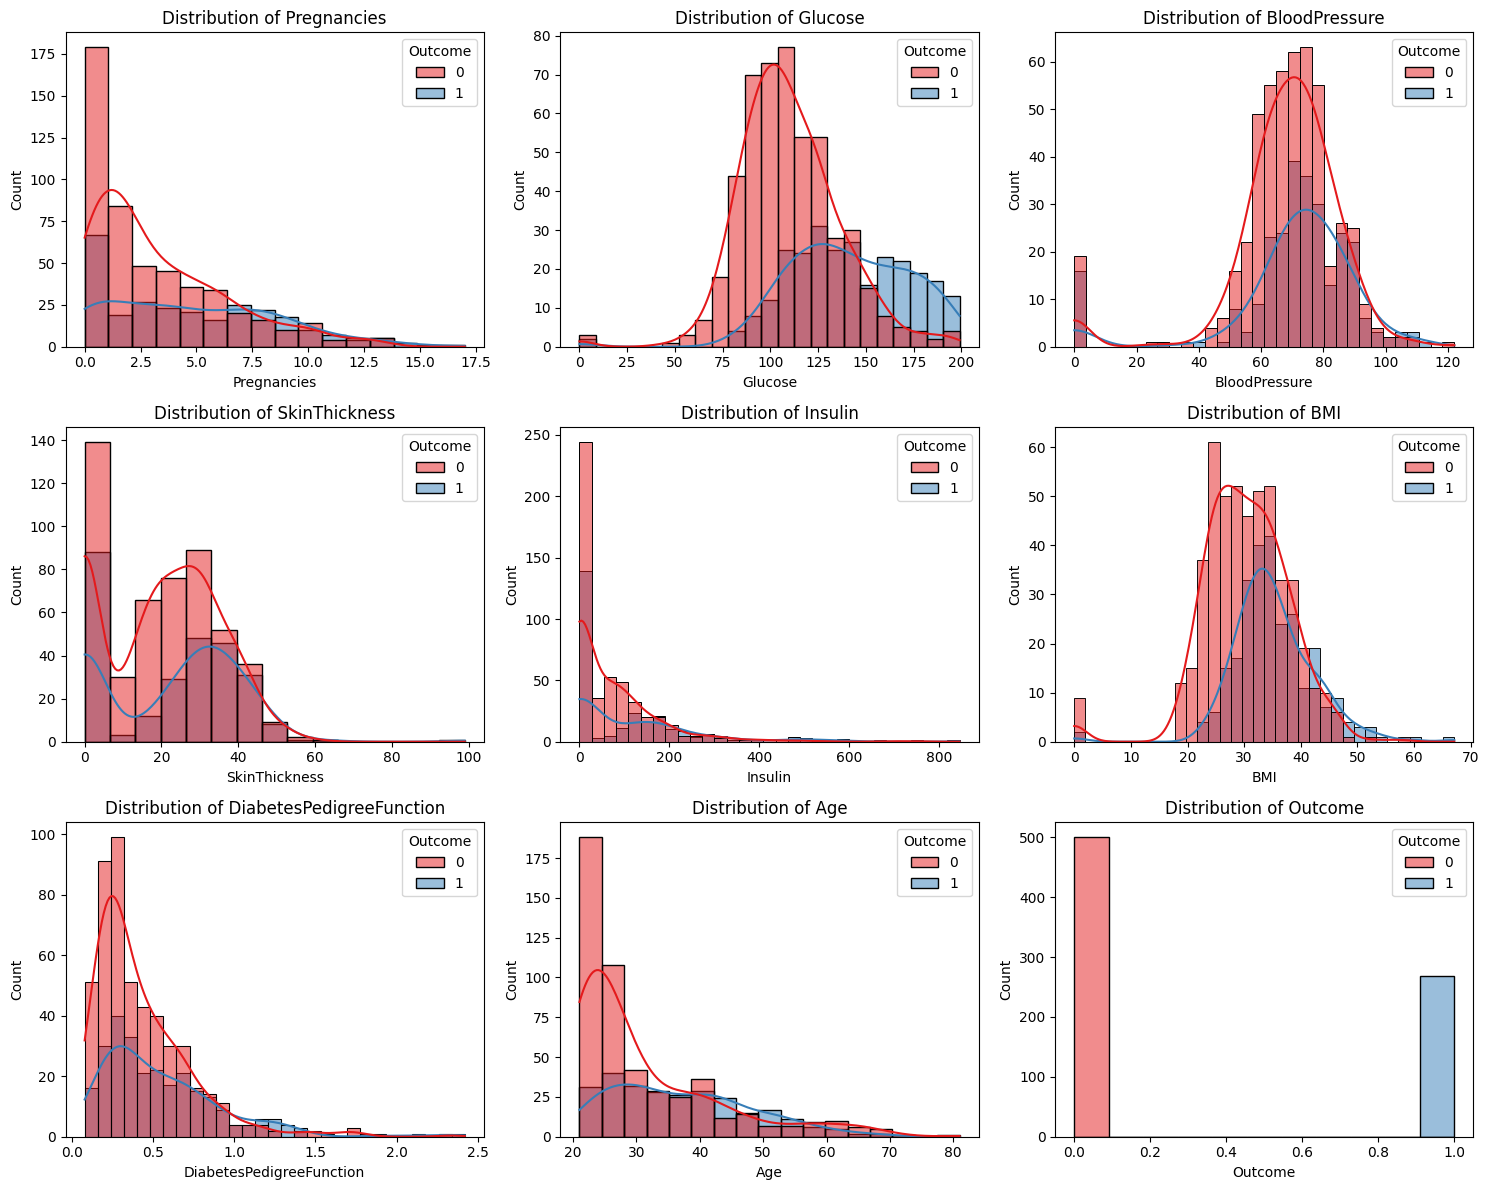

In [7]:
# Distribution of all features
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, column in enumerate(data.columns):
    sns.histplot(data=data, x=column, hue='Outcome', kde=True, ax=axes[idx], palette='Set1')
    axes[idx].set_title(f'Distribution of {column}')

plt.tight_layout()
plt.show()

C:\Users\Arnav pareek\AppData\Local\Temp\ipykernel_32944\3735685060.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y=column, data=data, ax=axes[idx], palette='Set2')
C:\Users\Arnav pareek\AppData\Local\Temp\ipykernel_32944\3735685060.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y=column, data=data, ax=axes[idx], palette='Set2')
C:\Users\Arnav pareek\AppData\Local\Temp\ipykernel_32944\3735685060.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y=column, data=data, ax=axes[idx], palette='Se

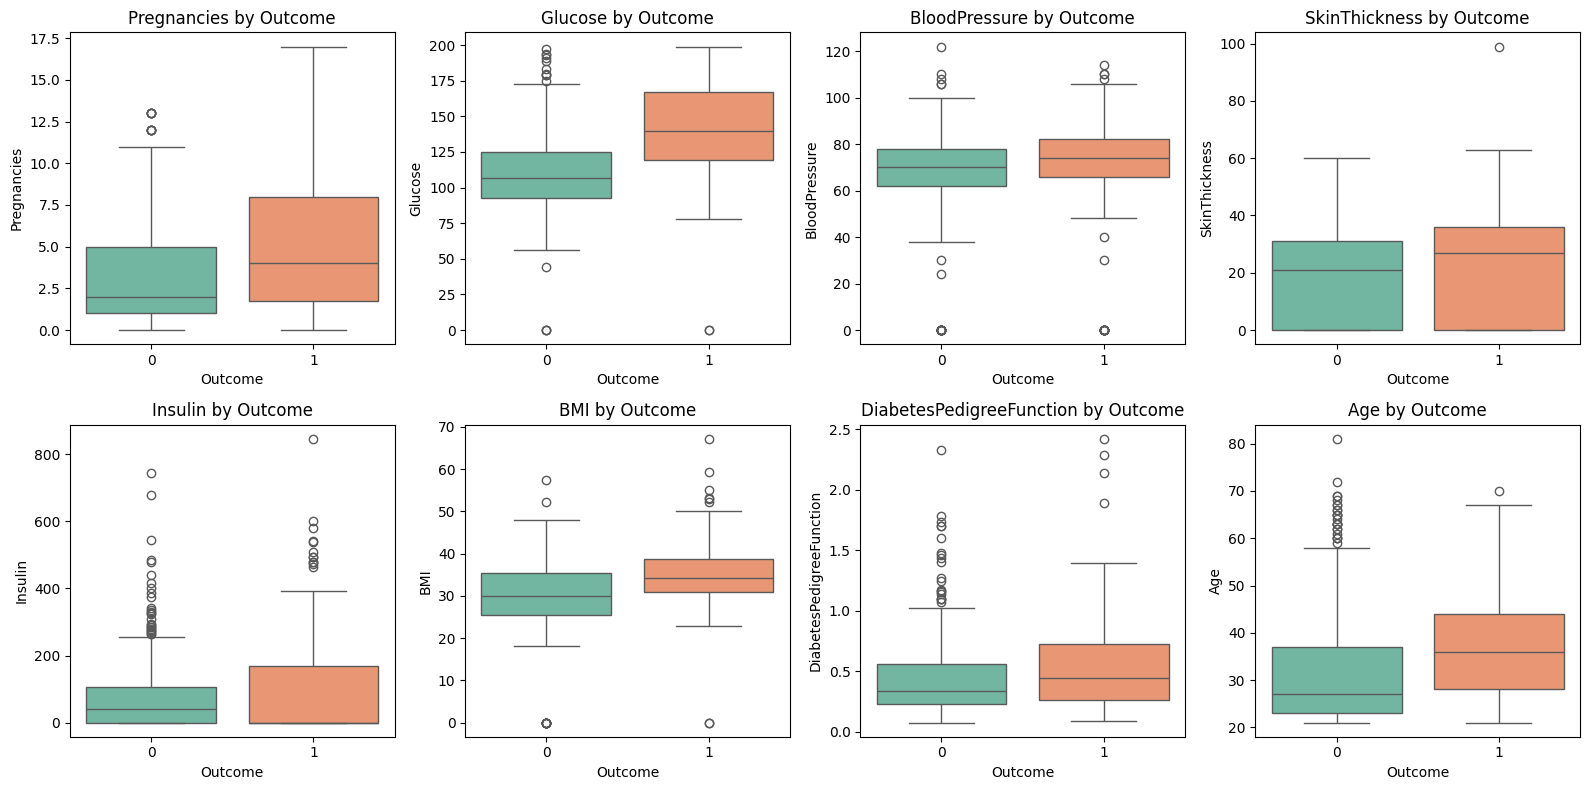

In [8]:
# Box plots to detect outliers
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, column in enumerate(data.columns[:-1]):  # Exclude 'Outcome'
    sns.boxplot(x='Outcome', y=column, data=data, ax=axes[idx], palette='Set2')
    axes[idx].set_title(f'{column} by Outcome')

plt.tight_layout()
plt.show()

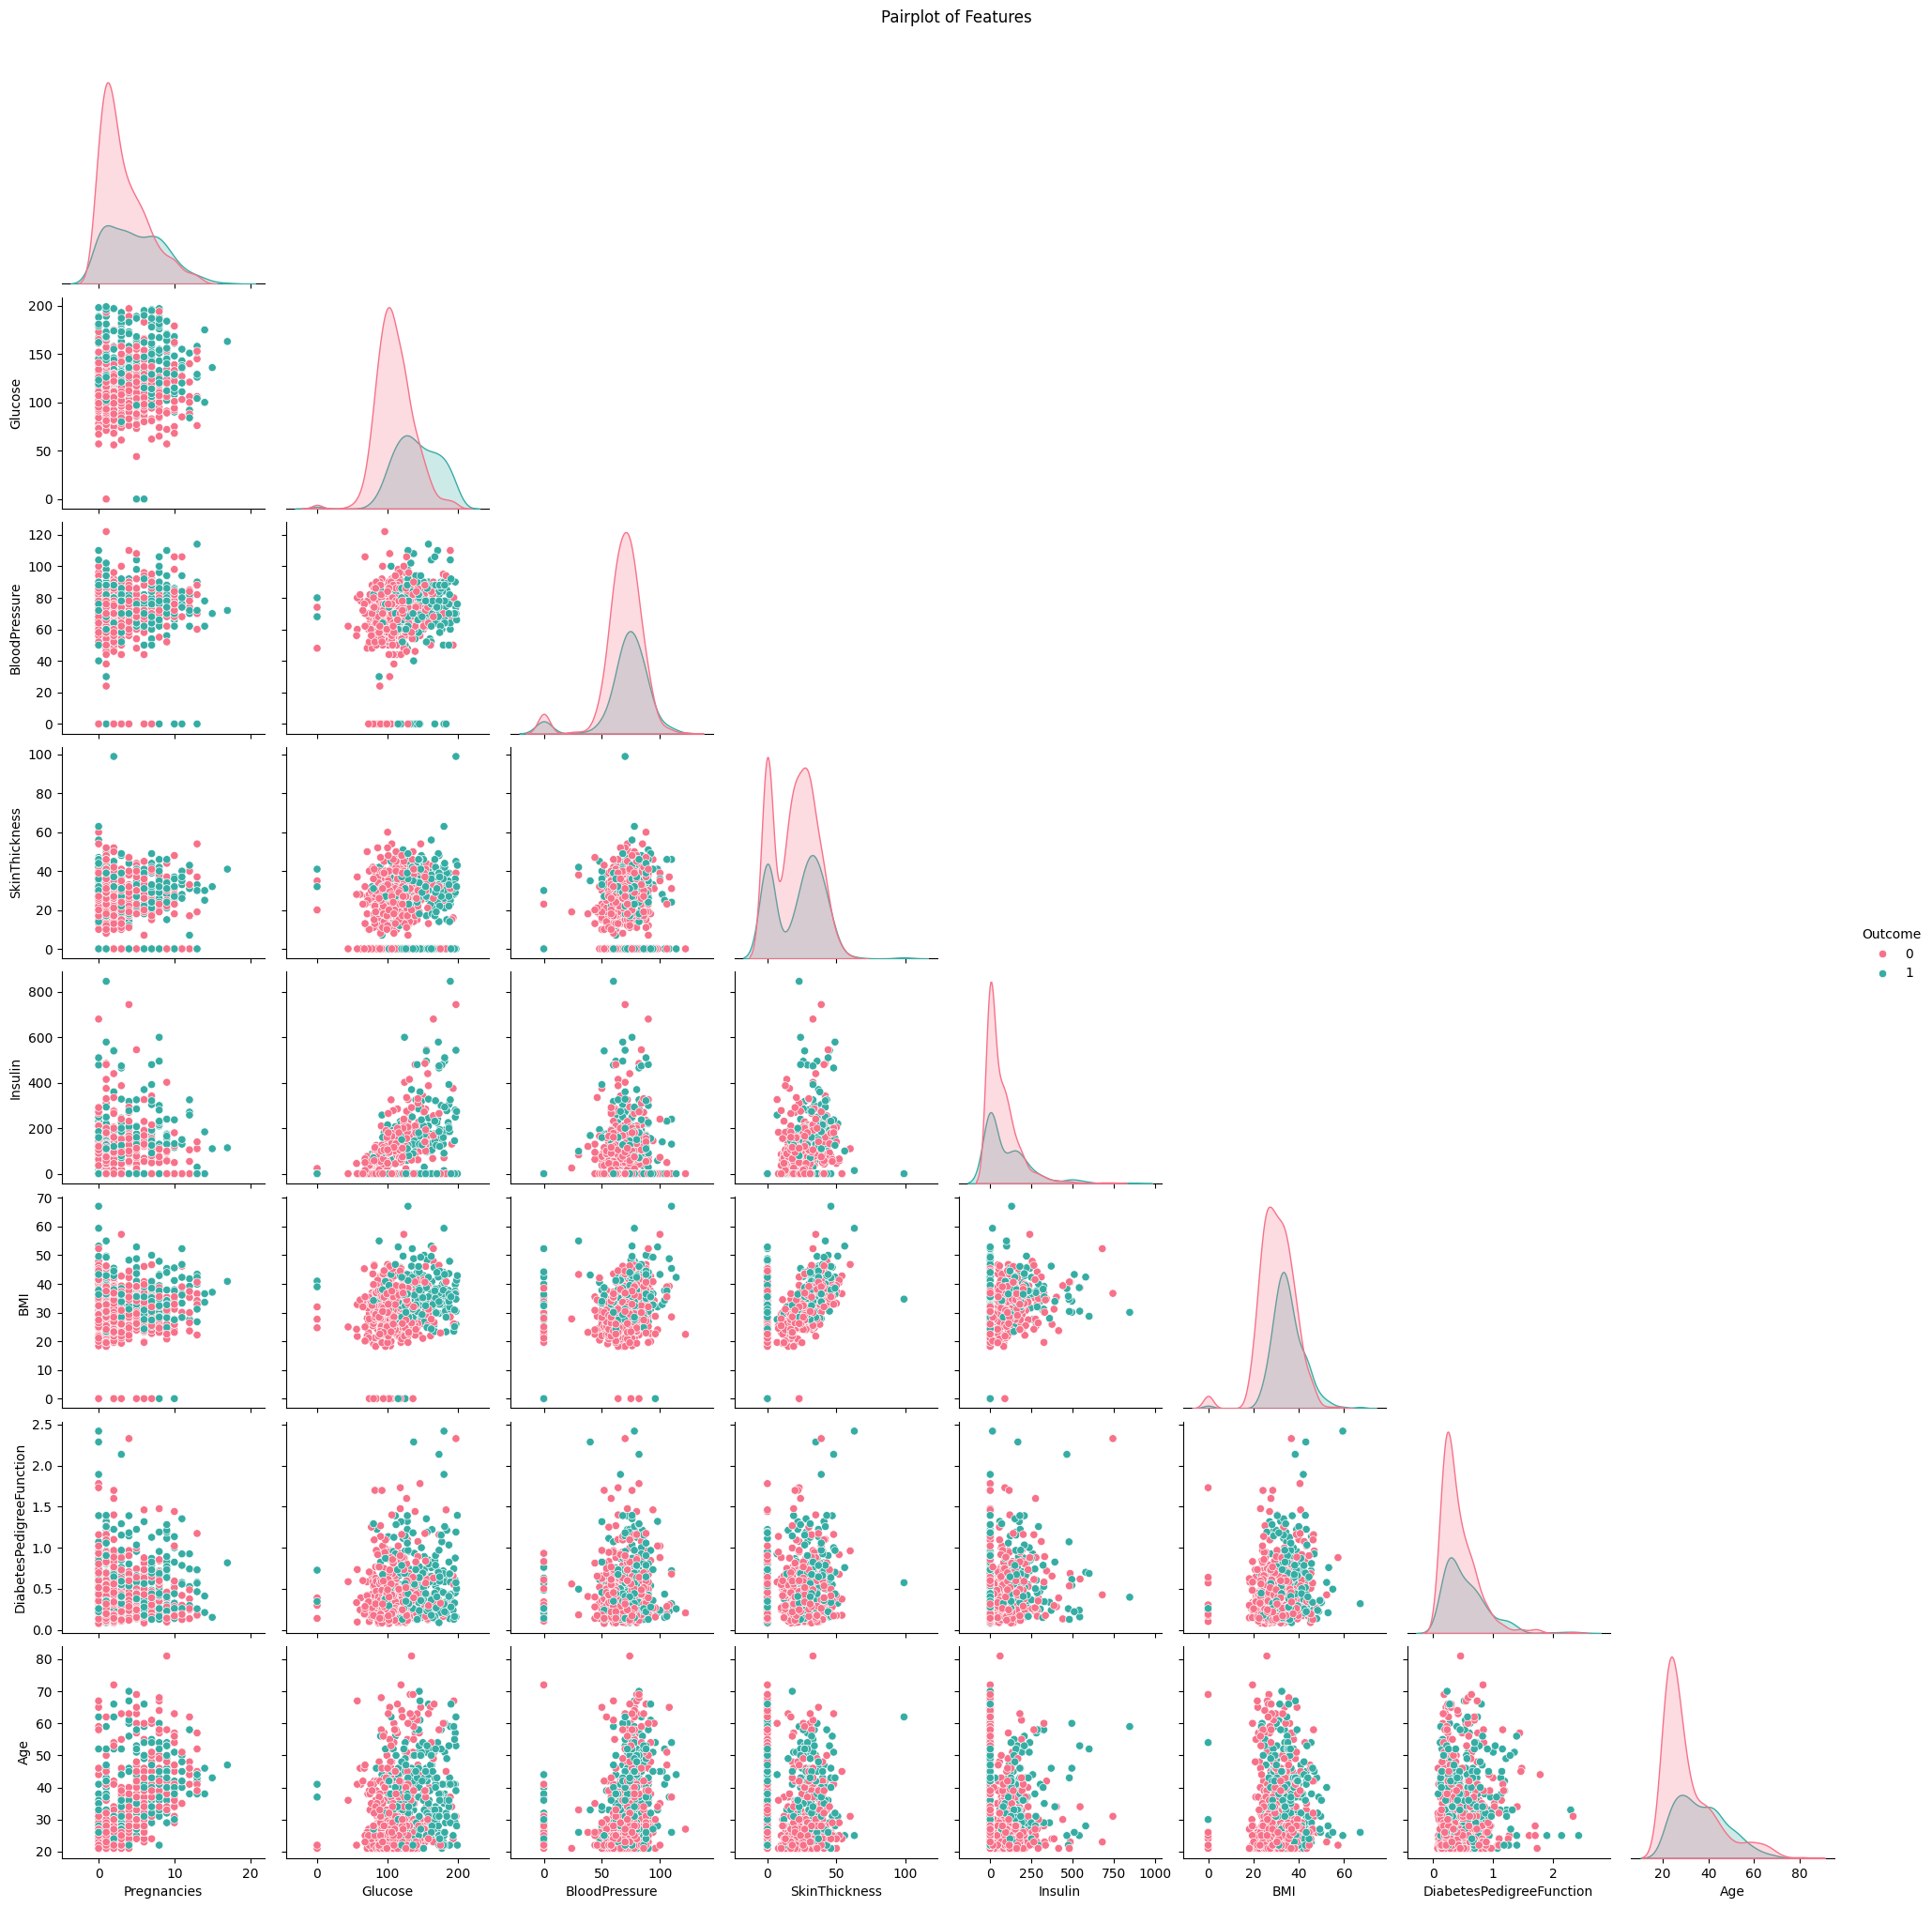

In [9]:
# Pairplot for feature relationships
sns.pairplot(data, hue='Outcome', palette='husl', diag_kind='kde', corner=True)
plt.suptitle('Pairplot of Features', y=1.02)
plt.show()

## 2. Model Training & Prediction

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression model
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = lr_model.predict(X_test_scaled)
y_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate the model
print("Logistic Regression Results:")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Logistic Regression Results:
Accuracy: 0.7532

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



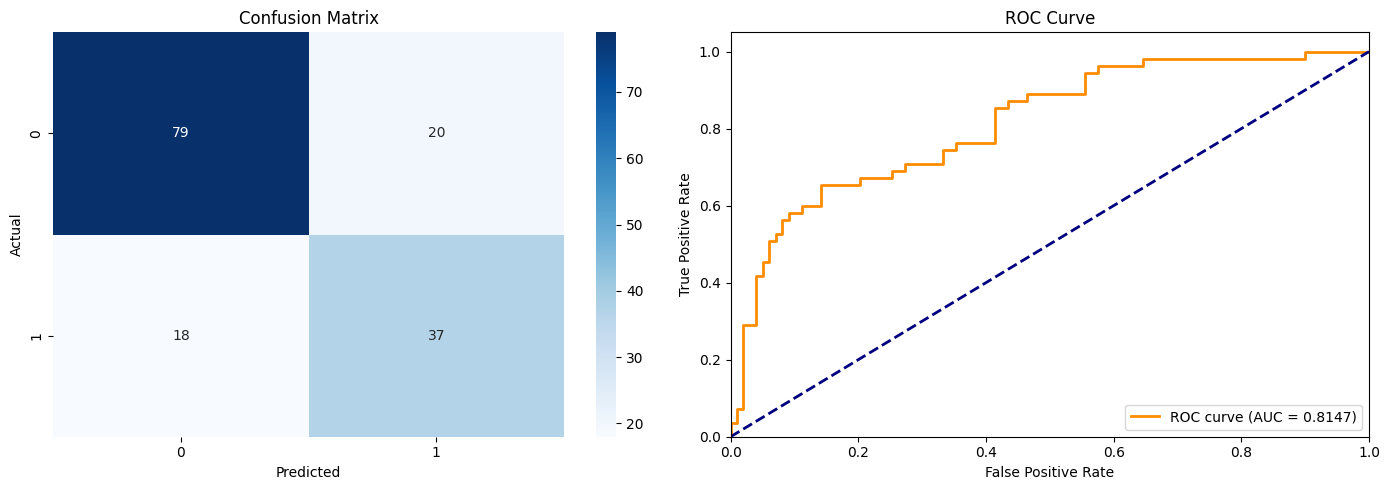

In [11]:
# Confusion Matrix Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

## 3. Bias-Variance Analysis

In [12]:
from sklearn.model_selection import cross_val_score, learning_curve
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# Calculate training and test scores for bias-variance analysis
def calculate_bias_variance(model, X_train, X_test, y_train, y_test, model_name):
    """Calculate bias and variance indicators"""
    model.fit(X_train, y_train)
    
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    
    # Cross-validation for variance estimation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5)
    
    bias = 1 - train_score  # High bias = low training accuracy
    variance = cv_scores.std()  # High variance = high std in CV scores
    
    print(f"\n{model_name}:")
    print(f"  Training Accuracy: {train_score:.4f}")
    print(f"  Test Accuracy: {test_score:.4f}")
    print(f"  CV Mean Score: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")
    print(f"  Bias (1-train_score): {bias:.4f} {'(High Bias - Underfitting)' if bias > 0.15 else '(Low Bias)'}")
    print(f"  Variance (CV std): {variance:.4f} {'(High Variance - Overfitting)' if variance > 0.05 else '(Low Variance)'}")
    print(f"  Gap (train-test): {train_score - test_score:.4f}")
    
    return train_score, test_score, cv_scores.mean(), variance

# Compare multiple models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(random_state=42)
}

print("=" * 60)
print("BIAS-VARIANCE ANALYSIS FOR DIFFERENT MODELS")
print("=" * 60)

results = {}
for name, model in models.items():
    results[name] = calculate_bias_variance(model, X_train_scaled, X_test_scaled, y_train, y_test, name)

BIAS-VARIANCE ANALYSIS FOR DIFFERENT MODELS

Logistic Regression:
  Training Accuracy: 0.7704
  Test Accuracy: 0.7532
  CV Mean Score: 0.7606 (+/- 0.0599)
  Bias (1-train_score): 0.2296 (High Bias - Underfitting)
  Variance (CV std): 0.0299 (Low Variance)
  Gap (train-test): 0.0171

Decision Tree:
  Training Accuracy: 1.0000
  Test Accuracy: 0.7468
  CV Mean Score: 0.7198 (+/- 0.1039)
  Bias (1-train_score): 0.0000 (Low Bias)
  Variance (CV std): 0.0520 (High Variance - Overfitting)
  Gap (train-test): 0.2532

Random Forest:
  Training Accuracy: 1.0000
  Test Accuracy: 0.7208
  CV Mean Score: 0.7753 (+/- 0.0680)
  Bias (1-train_score): 0.0000 (Low Bias)
  Variance (CV std): 0.0340 (Low Variance)
  Gap (train-test): 0.2792

Gradient Boosting:
  Training Accuracy: 0.9381
  Test Accuracy: 0.7403
  CV Mean Score: 0.7704 (+/- 0.0473)
  Bias (1-train_score): 0.0619 (Low Bias)
  Variance (CV std): 0.0236 (Low Variance)
  Gap (train-test): 0.1979

SVM:
  Training Accuracy: 0.8339
  Test Accura

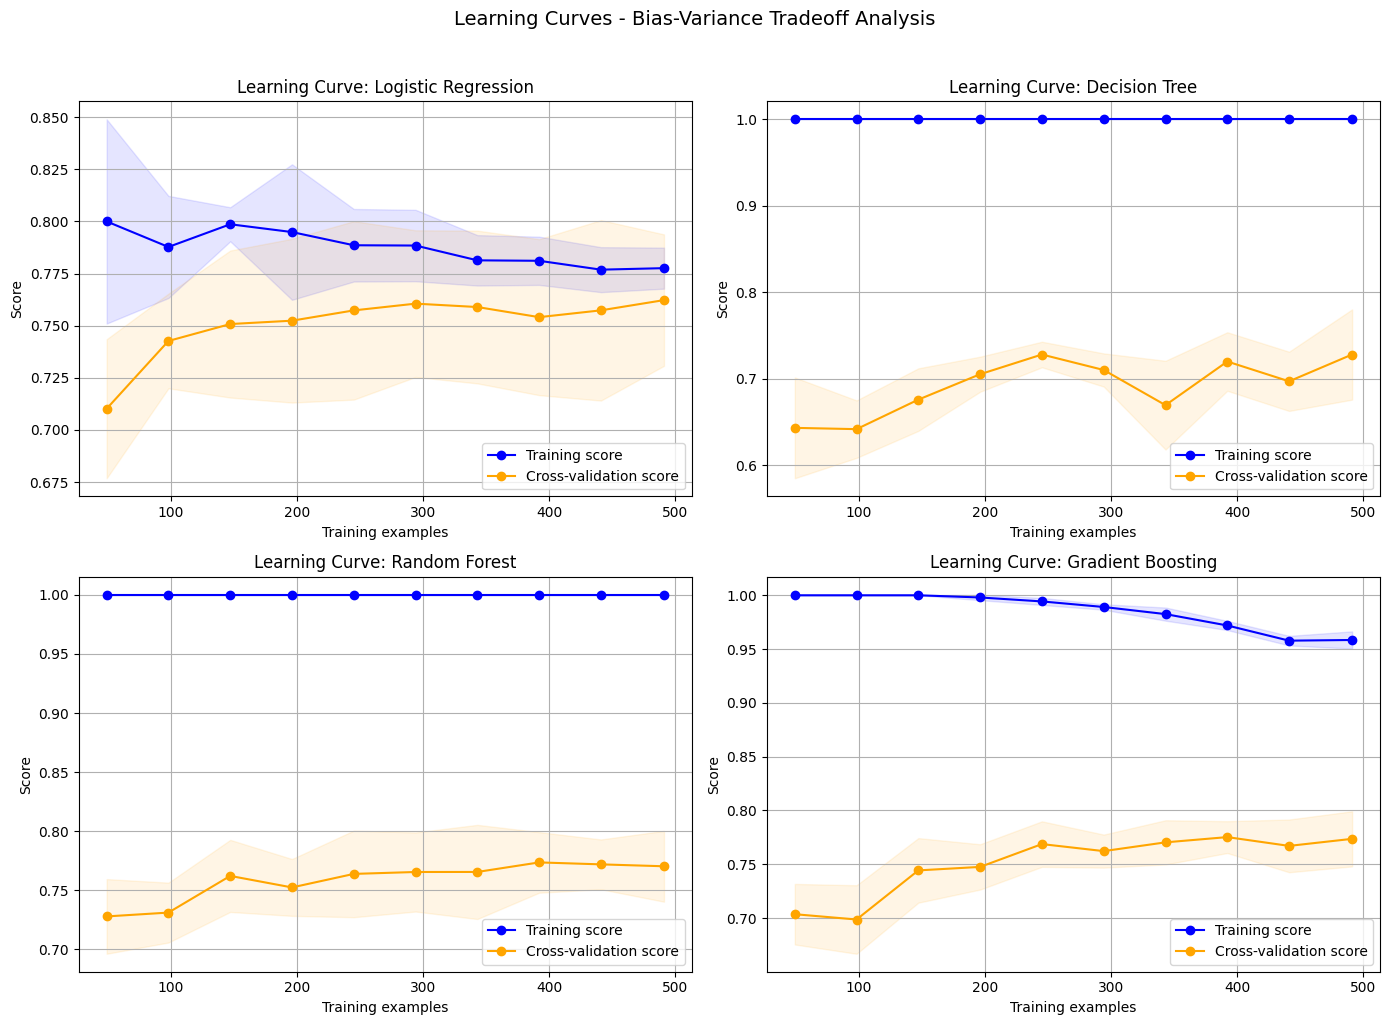


Learning Curve Interpretation:
- If both curves converge at low score → High Bias (underfitting)
- If large gap between curves → High Variance (overfitting)
- If both curves converge at high score → Good fit


In [13]:
# Learning Curves for Bias-Variance Visualization
def plot_learning_curve(estimator, X, y, title, ax, cv=5):
    """Plot learning curve to visualize bias-variance tradeoff"""
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy', random_state=42
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
    ax.plot(train_sizes, train_mean, 'o-', color='blue', label='Training score')
    ax.plot(train_sizes, test_mean, 'o-', color='orange', label='Cross-validation score')
    ax.set_xlabel('Training examples')
    ax.set_ylabel('Score')
    ax.set_title(title)
    ax.legend(loc='lower right')
    ax.grid(True)

# Plot learning curves for key models
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

models_to_plot = [
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
    ('Decision Tree', DecisionTreeClassifier(random_state=42)),
    ('Random Forest', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('Gradient Boosting', GradientBoostingClassifier(n_estimators=100, random_state=42))
]

for idx, (name, model) in enumerate(models_to_plot):
    plot_learning_curve(model, X_train_scaled, y_train, f'Learning Curve: {name}', axes[idx])

plt.suptitle('Learning Curves - Bias-Variance Tradeoff Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nLearning Curve Interpretation:")
print("- If both curves converge at low score → High Bias (underfitting)")
print("- If large gap between curves → High Variance (overfitting)")
print("- If both curves converge at high score → Good fit")

## 4. Model Adjustment & Optimization

In [14]:
from sklearn.model_selection import GridSearchCV

# Adjusting models based on bias-variance analysis

# 1. Regularization for Logistic Regression (reduce variance)
print("=" * 60)
print("OPTIMIZING LOGISTIC REGRESSION (Regularization)")
print("=" * 60)

lr_params = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

lr_grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), 
                        lr_params, cv=5, scoring='accuracy', n_jobs=-1)
lr_grid.fit(X_train_scaled, y_train)

print(f"Best parameters: {lr_grid.best_params_}")
print(f"Best CV score: {lr_grid.best_score_:.4f}")
print(f"Test score: {lr_grid.score(X_test_scaled, y_test):.4f}")

OPTIMIZING LOGISTIC REGRESSION (Regularization)
Best parameters: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV score: 0.7655
Test score: 0.7532


C:\Users\Arnav pareek\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [15]:
# 2. Decision Tree Pruning (reduce variance/overfitting)
print("\n" + "=" * 60)
print("OPTIMIZING DECISION TREE (Pruning)")
print("=" * 60)

dt_params = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10]
}

dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), 
                        dt_params, cv=5, scoring='accuracy', n_jobs=-1)
dt_grid.fit(X_train_scaled, y_train)

print(f"Best parameters: {dt_grid.best_params_}")
print(f"Best CV score: {dt_grid.best_score_:.4f}")
print(f"Test score: {dt_grid.score(X_test_scaled, y_test):.4f}")


OPTIMIZING DECISION TREE (Pruning)
Best parameters: {'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best CV score: 0.7671
Test score: 0.7792


In [16]:
# 3. Random Forest Tuning (balance bias-variance)
print("\n" + "=" * 60)
print("OPTIMIZING RANDOM FOREST")
print("=" * 60)

rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), 
                        rf_params, cv=5, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train_scaled, y_train)

print(f"Best parameters: {rf_grid.best_params_}")
print(f"Best CV score: {rf_grid.best_score_:.4f}")
print(f"Test score: {rf_grid.score(X_test_scaled, y_test):.4f}")


OPTIMIZING RANDOM FOREST
Best parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
Best CV score: 0.7851
Test score: 0.7468



FINAL MODEL COMPARISON (After Optimization)


C:\Users\Arnav pareek\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Arnav pareek\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


                        Model  Train Accuracy  Test Accuracy  CV Mean   CV Std     Bias  train-test Gap
Optimized Logistic Regression        0.770358       0.753247 0.765507 0.027605 0.229642        0.017112
      Optimized Decision Tree        0.822476       0.779221 0.767120 0.015652 0.177524        0.043255
      Optimized Random Forest        0.916938       0.746753 0.785073 0.032447 0.083062        0.170185


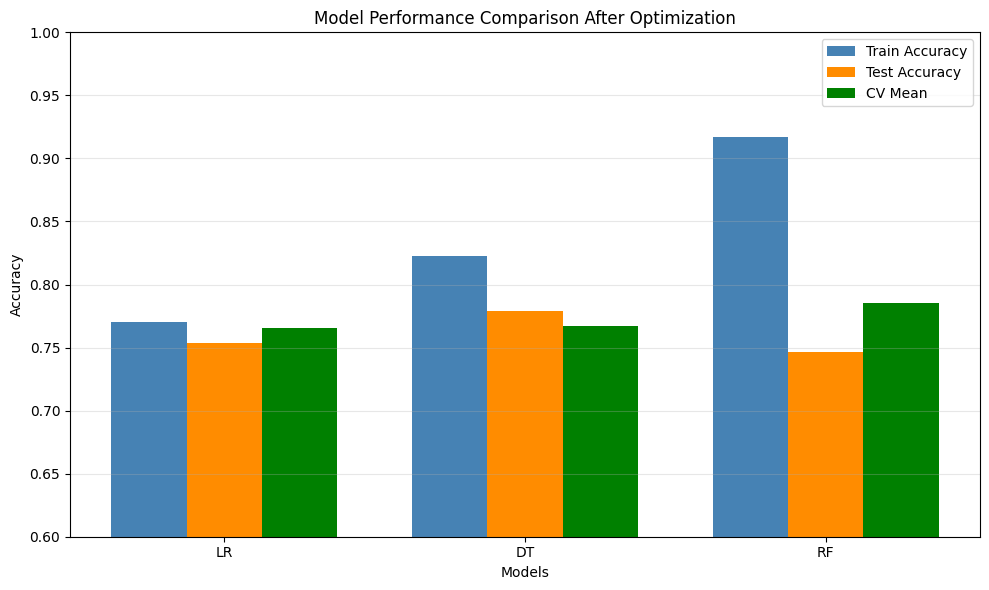

In [17]:
# Final Model Comparison
print("\n" + "=" * 60)
print("FINAL MODEL COMPARISON (After Optimization)")
print("=" * 60)

final_models = {
    'Optimized Logistic Regression': lr_grid.best_estimator_,
    'Optimized Decision Tree': dt_grid.best_estimator_,
    'Optimized Random Forest': rf_grid.best_estimator_
}

comparison_results = []
for name, model in final_models.items():
    train_acc = model.score(X_train_scaled, y_train)
    test_acc = model.score(X_test_scaled, y_test)
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    
    comparison_results.append({
        'Model': name,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc,
        'CV Mean': cv_scores.mean(),
        'CV Std': cv_scores.std(),
        'Bias': 1 - train_acc,
        'train-test Gap': train_acc - test_acc
    })

comparison_df = pd.DataFrame(comparison_results)
print(comparison_df.to_string(index=False))

# Visualization of model comparison
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison_df))
width = 0.25

bars1 = ax.bar(x - width, comparison_df['Train Accuracy'], width, label='Train Accuracy', color='steelblue')
bars2 = ax.bar(x, comparison_df['Test Accuracy'], width, label='Test Accuracy', color='darkorange')
bars3 = ax.bar(x + width, comparison_df['CV Mean'], width, label='CV Mean', color='green')

ax.set_xlabel('Models')
ax.set_ylabel('Accuracy')
ax.set_title('Model Performance Comparison After Optimization')
ax.set_xticks(x)
ax.set_xticklabels(['LR', 'DT', 'RF'], rotation=0)
ax.legend()
ax.set_ylim([0.6, 1.0])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


FEATURE IMPORTANCE (Random Forest)
                    Feature  Importance
1                   Glucose    0.328683
5                       BMI    0.179653
7                       Age    0.143652
6  DiabetesPedigreeFunction    0.098529
4                   Insulin    0.069451
0               Pregnancies    0.063039
2             BloodPressure    0.062567
3             SkinThickness    0.054426


C:\Users\Arnav pareek\AppData\Local\Temp\ipykernel_32944\2558756097.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')


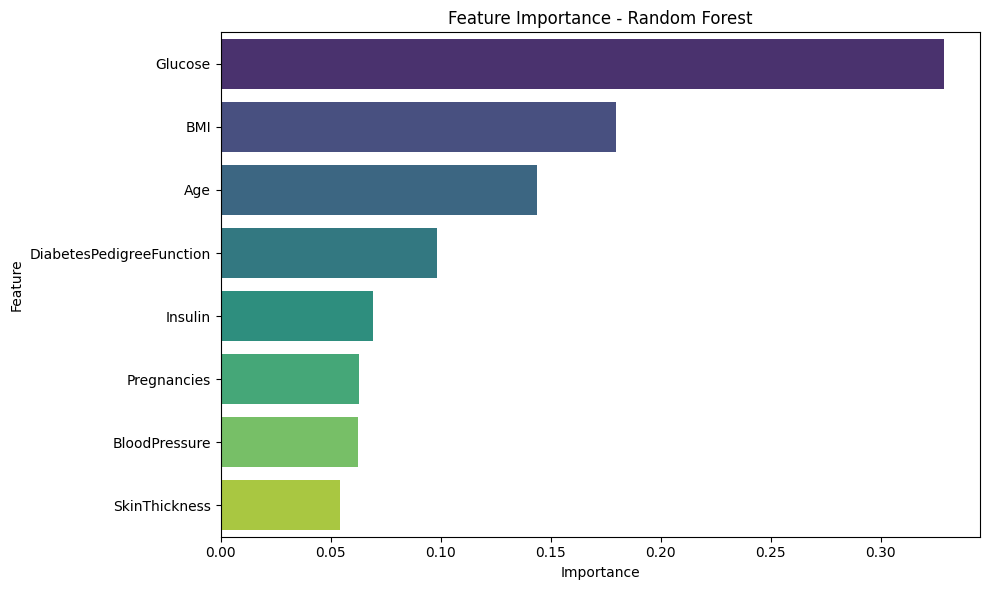

In [18]:
# Feature Importance from Best Model (Random Forest)
print("\n" + "=" * 60)
print("FEATURE IMPORTANCE (Random Forest)")
print("=" * 60)

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_grid.best_estimator_.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 5. Final Predictions & Summary

BEST MODEL: Optimized Decision Tree

Test Accuracy: 0.7792

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.83        99
           1       0.71      0.65      0.68        55

    accuracy                           0.78       154
   macro avg       0.76      0.75      0.76       154
weighted avg       0.78      0.78      0.78       154



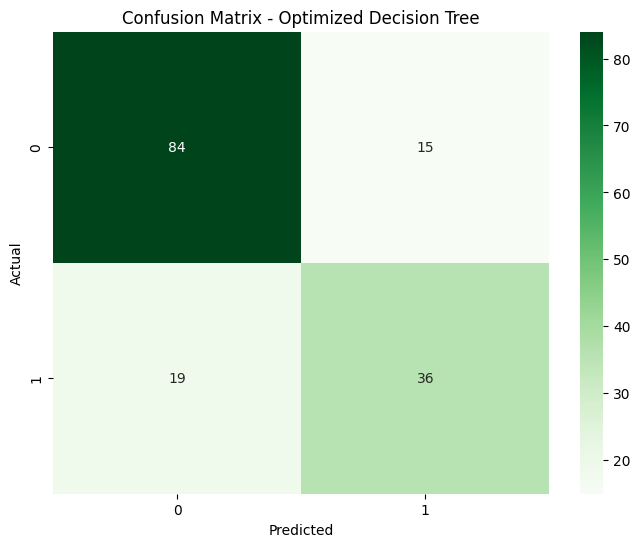


SUMMARY - BIAS-VARIANCE TRADEOFF

Key Findings:
1. Decision Trees typically show HIGH VARIANCE (overfitting)
   - Solution: Pruning (max_depth, min_samples_split/leaf)

2. Logistic Regression may show HIGH BIAS (underfitting)
   - Solution: Add polynomial features, reduce regularization

3. Random Forest often achieves a good BIAS-VARIANCE BALANCE
   - Ensemble method reduces variance while maintaining low bias

4. Regularization (L1/L2) helps control variance in linear models

Recommendations:
- Choose model based on the bias-variance tradeoff observed
- Use cross-validation to estimate generalization performance
- Monitor learning curves to diagnose issues



In [19]:
# Select the best model based on test accuracy
best_model_name = comparison_df.loc[comparison_df['Test Accuracy'].idxmax(), 'Model']
best_model = final_models[best_model_name]

print("=" * 60)
print(f"BEST MODEL: {best_model_name}")
print("=" * 60)

# Final predictions with best model
final_predictions = best_model.predict(X_test_scaled)
final_proba = best_model.predict_proba(X_test_scaled) if hasattr(best_model, 'predict_proba') else None

print(f"\nTest Accuracy: {accuracy_score(y_test, final_predictions):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, final_predictions))

# Confusion Matrix for best model
plt.figure(figsize=(8, 6))
cm_best = confusion_matrix(y_test, final_predictions)
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Greens')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Summary
print("\n" + "=" * 60)
print("SUMMARY - BIAS-VARIANCE TRADEOFF")
print("=" * 60)
print("""
Key Findings:
1. Decision Trees typically show HIGH VARIANCE (overfitting)
   - Solution: Pruning (max_depth, min_samples_split/leaf)

2. Logistic Regression may show HIGH BIAS (underfitting)
   - Solution: Add polynomial features, reduce regularization

3. Random Forest often achieves a good BIAS-VARIANCE BALANCE
   - Ensemble method reduces variance while maintaining low bias

4. Regularization (L1/L2) helps control variance in linear models

Recommendations:
- Choose model based on the bias-variance tradeoff observed
- Use cross-validation to estimate generalization performance
- Monitor learning curves to diagnose issues
""")